In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

In [2]:
#unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zona_logistica\esp840_1620_02_2026.csv',sep=',') #for csv files.
unit=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\el_cafetal\KFB408.xlsx') #For xls files.
unit.info()

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  41 non-null     str  
 1   Message  41 non-null     str  
 2   Status   41 non-null     str  
dtypes: str(3)
memory usage: 1.1 KB


Odometer

    Odometer in meters  Odometer en miles
0             79527003       49415.773381
1             79527003       49415.773381
2             79527003       49415.773381
3             79527003       49415.773381
4             79527003       49415.773381
5             79527003       49415.773381
6             79527003       49415.773381
7             79527003       49415.773381
8             79527003       49415.773381
9             79527008       49415.776488
10            79527081       49415.821848
11            79528158       49416.491065
12            79528203       49416.519026
13            79529440       49417.287662
14            79530893       49418.190514
15            79532372       49419.109522
16            79533433       49419.768797
17            79534681       49420.544268
18            79536518       49421.685726
19            79536518       49421.685726
20            79537814       49422.491023
21            79537837       49422.505315
22            79537954       49422

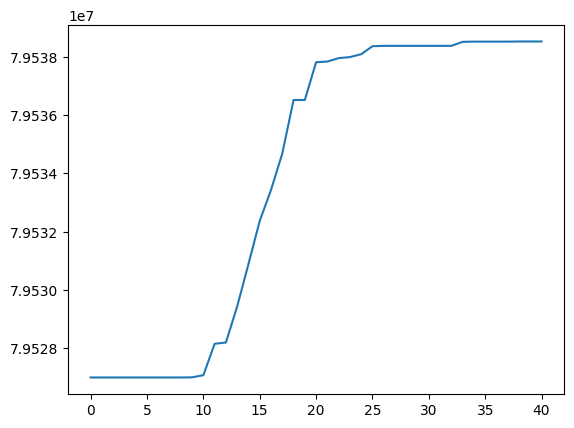

In [3]:
aux=[]
aux_miles=[]
x_axis=[]
unit_odometer=pd.DataFrame()
cont=0

for i in range (0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    #print('Len=',l)
    if l<180:
        aux.append(int(unit.iloc[i,2][68:76],16))
        aux_miles.append((int(unit.iloc[i,2][68:76],16))*0.000621371)
        cont=cont+1     

unit_odometer['Odometer in meters']=aux
unit_odometer['Odometer en miles']=aux_miles

for i in range(0,cont):
    x_axis.append(i)

print(unit_odometer)
unit_odometer
plt.plot(x_axis,aux)

Harsh turn

Event codes only for No User messages.
Harsh Turn: 35 on Hex, 53 on Dec

In [4]:
event_code=[]

for i in range(0,unit.shape[0]):
    event_code.append(unit.iloc[i,2][64:68])
    if unit.iloc[i,2][64:66]=='35': # Put the Even Code to look for.
        print(unit.iloc[i,2][64:66],' -> ',unit.iloc[i,0])

Satellite number

In [5]:
cont=0
for i in range(0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    if l>92:
        sn=int(unit.iloc[i,2][82:84],16)        
        if sn<5:
            print(unit.iloc[i,0], ' -> ',sn)
            cont=cont+1
    if l<93:
        sn=int(unit.iloc[i,2][55:57],16)        
        if sn<5:
            print(unit.iloc[i,0], ' -> ',sn)
            cont=cont+1

print('Messages with satellite number < 5: ',cont)
        

2026-05-06 01:36:28.317  ->  0
2026-05-06 01:36:28.796  ->  0
2026-05-06 01:36:29.248  ->  0
2026-05-06 01:36:29.690  ->  0
2026-05-06 01:36:30.124  ->  0
2026-05-06 01:36:30.568  ->  0
2026-05-06 01:36:31.131  ->  0
2026-05-06 01:36:32.403  ->  0
2026-05-06 01:36:33.332  ->  0
2026-05-06 13:06:18.998  ->  0
2026-05-06 13:06:19.433  ->  0
2026-05-06 13:06:19.922  ->  0
2026-05-06 13:06:20.398  ->  0
2026-05-06 13:06:20.854  ->  0
2026-05-06 13:06:22.050  ->  0
2026-05-06 13:10:47.874  ->  0
2026-05-06 14:59:11.029  ->  0
2026-05-06 14:59:11.535  ->  0
2026-05-06 14:59:11.932  ->  0
2026-05-06 15:03:27.919  ->  0
Messages with satellite number < 5:  20


iButton

In [6]:
aux_temp=[]
for i in range(0,unit.shape[0]):    
    aux_temp.append(unit.iloc[i,2][108:124])
aux_temp

['',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '']

Binary inputs

In [7]:
for i in range(0,unit.shape[0]):   
    if unit.iloc[i,2][64:66]=='0C': # Put the Even Code to look for.
        cont=cont+1
        print(bin(int(unit.iloc[i,2][62:64],16)),' -> ',unit.iloc[i,0])
print("Total event codes 0C input2 Off: ",cont)

Total event codes 0C input2 Off:  20


In [8]:
sequence=[]
sequence.append(unit.iloc[0,2][24:28])
sequence

['0001']

[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 13, 3, 21, 48, 41, 10, 27, 57, 35, 35, 16, 0, 31, 26, 44, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] 41


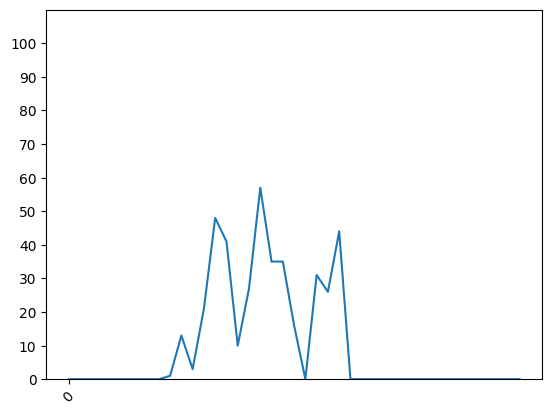

In [9]:
aux=[]
aux_kmh=[]
x_axis=[]
unit_speed=pd.DataFrame()
cont=0

for i in range (0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    #print('Len=',l)
    if l<180:
        aux.append(int(unit.iloc[i,2][56:58],16))
        #aux_kmh.append((int(unit.iloc[i,2][68:76],16))*0.036)
        cont=cont+1     

unit_speed['Speed Km-h']=aux
#unit_speed['Speed m-s']=aux_kmh

for i in range(0,cont):
    x_axis.append(i)

print(aux,cont)

plt.xticks(range(0,1100,100),rotation=45)
plt.yticks(range(0,110,10))
plt.ylim(0,110)
plt.plot(x_axis,aux)

Idle alert:

In [10]:
unit=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\don_pollo\Export.xlsx') #For xls files.
idle_alert_events=pd.DataFrame()

event_code=[]
date_event_code=[]

for i in range(0,unit.shape[0]):
    #event_code.append(unit.iloc[i,2][64:68])
    if unit.iloc[i,2][64:66]=='2D': # Put the Even Code to look for.
        event_code.append(unit.iloc[i,2][64:66])
        date_event_code.append(unit.iloc[i,0])
        #print(unit.iloc[i,2][64:66],' -> ',unit.iloc[i,0])


idle_alert_events['Date']=date_event_code
idle_alert_events['Event']=event_code

idle_alert_events.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\don_pollo\idle_alert_events.csv')

print(idle_alert_events)

                      Date Event
0  2026-05-13 08:24:20.917    2D
1  2026-05-13 12:02:53.099    2D
2  2026-05-13 16:15:29.916    2D
3  2026-05-13 17:04:08.623    2D
4  2026-05-14 08:24:37.782    2D
5  2026-05-14 11:22:32.245    2D
6  2026-05-14 11:46:49.962    2D
7  2026-05-14 11:58:59.916    2D
8  2026-05-14 13:14:16.054    2D
9  2026-05-14 14:21:44.128    2D


Ignition on:

In [11]:
ignition_on=pd.DataFrame()
event_code=[]
date_event_code=[]
date_real_code=[]
hex_epoch=[]
var_epoch=[]

for i in range(0,unit.shape[0]):
    #event_code.append(unit.iloc[i,2][64:68])
    if unit.iloc[i,2][64:66]=='01': # Put the Even Code to look for.
        event_code.append(unit.iloc[i,2][64:66])
        date_event_code.append(unit.iloc[i,0])
        var_dec=int(unit.iloc[i,2][28:36],16)
        var_epoch.append(var_dec)
        aux_date=datetime.datetime.fromtimestamp(var_dec)#,tz=timezone.utc)
        date_real_code.append(aux_date)
        hex_epoch.append(unit.iloc[i,2][28:36])
        #print(unit.iloc[i,2][64:66],' -> ',unit.iloc[i,0])


ignition_on['Receive_Date']=date_event_code
ignition_on['Event']=event_code
ignition_on['Date_real_Event']=date_real_code
ignition_on['Epoch']=var_epoch
#ignition_on['hex_epoch']=hex_epoch

print(ignition_on)

ignition_on.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\gtc\ignition_on.csv')

               Receive_Date Event     Date_real_Event       Epoch
0   2026-05-13 08:19:16.655    01 2026-05-13 03:20:44  1778660444
1   2026-05-13 08:59:36.615    01 2026-05-13 04:01:04  1778662864
2   2026-05-13 09:22:01.989    01 2026-05-13 04:23:30  1778664210
3   2026-05-13 09:33:42.530    01 2026-05-13 04:35:10  1778664910
4   2026-05-13 09:39:43.937    01 2026-05-13 04:40:40  1778665240
5   2026-05-13 09:44:10.454    01 2026-05-13 04:45:07  1778665507
6   2026-05-13 09:49:02.180    01 2026-05-13 04:50:30  1778665830
7   2026-05-13 10:32:50.381    01 2026-05-13 05:33:47  1778668427
8   2026-05-13 11:13:44.344    01 2026-05-13 06:13:43  1778670823
9   2026-05-13 11:26:50.585    01 2026-05-13 06:26:49  1778671609
10  2026-05-13 11:34:38.049    01 2026-05-13 06:34:37  1778672077
11  2026-05-13 11:49:31.135    01 2026-05-13 06:49:31  1778672971
12  2026-05-13 13:02:31.586    01 2026-05-13 08:02:30  1778677350
13  2026-05-13 14:00:56.575    01 2026-05-13 09:00:55  1778680855
14  2026-0

Ignition off:


In [12]:
ignition_off=pd.DataFrame()

event_code=[]
date_event_code=[]
date_real_code=[]
var_epoch=[]

for i in range(0,unit.shape[0]):
    #event_code.append(unit.iloc[i,2][64:68])
    if unit.iloc[i,2][64:66]=='02': # Put the Even Code to look for.
        event_code.append(unit.iloc[i,2][64:66])
        date_event_code.append(unit.iloc[i,0])
        var_dec=int(unit.iloc[i,2][28:36],16)
        var_epoch.append(var_dec)
        aux_date=datetime.datetime.fromtimestamp(var_dec)
        date_real_code.append(aux_date)
        #print(unit.iloc[i,2][64:66],' -> ',unit.iloc[i,0])


ignition_off['Receive_Date']=date_event_code
ignition_off['Event']=event_code
ignition_off['Date_real_Event']=date_real_code
ignition_off['Epoch']=var_epoch

print(ignition_on)

ignition_on.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\gtc\ignition_off.csv')

               Receive_Date Event     Date_real_Event       Epoch
0   2026-05-13 08:19:16.655    01 2026-05-13 03:20:44  1778660444
1   2026-05-13 08:59:36.615    01 2026-05-13 04:01:04  1778662864
2   2026-05-13 09:22:01.989    01 2026-05-13 04:23:30  1778664210
3   2026-05-13 09:33:42.530    01 2026-05-13 04:35:10  1778664910
4   2026-05-13 09:39:43.937    01 2026-05-13 04:40:40  1778665240
5   2026-05-13 09:44:10.454    01 2026-05-13 04:45:07  1778665507
6   2026-05-13 09:49:02.180    01 2026-05-13 04:50:30  1778665830
7   2026-05-13 10:32:50.381    01 2026-05-13 05:33:47  1778668427
8   2026-05-13 11:13:44.344    01 2026-05-13 06:13:43  1778670823
9   2026-05-13 11:26:50.585    01 2026-05-13 06:26:49  1778671609
10  2026-05-13 11:34:38.049    01 2026-05-13 06:34:37  1778672077
11  2026-05-13 11:49:31.135    01 2026-05-13 06:49:31  1778672971
12  2026-05-13 13:02:31.586    01 2026-05-13 08:02:30  1778677350
13  2026-05-13 14:00:56.575    01 2026-05-13 09:00:55  1778680855
14  2026-0